Добавление товаров

Создайте программу, которая подключается к MongoDB и:
- выбирает базу ich_edit и коллекцию products_<your_group>_<your_full_name>
- очищает коллекцию перед началом
- добавляет 3 товара с полями: name, price, stock
- выводит сообщение о количестве добавленных товаров

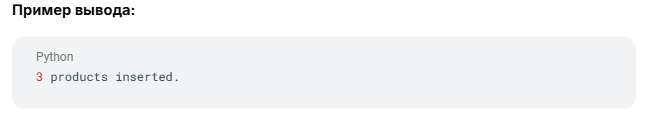

In [12]:
import pymongo
conn_edit = pymongo.MongoClient(
    "mongodb://<username>:<password>@<host>/?authSource=<database>"
)
edit_db = conn_edit["YOUR_DB"]
collection = edit_db["120925_Honcharov_Vitalii"]
collection.delete_many({})
products = [
    {"name": "Laptop", "price": 999.99, "stock": "available"},
    {"name": "Smartphone", "price": 499.99, "stock": "not available"},
    {"name": "Headphones", "price": 199.99, "stock": "available"}
]
collection.insert_many(products)
print(f"{len(products)} products inserted.")


3 products inserted.


Увеличение цен

Продолжите предыдущую задачу. Теперь программа должна:
- увеличить цену всех товаров на 20%
- вывести количество обновлённых записей
- затем вывести список всех товаров с новыми ценами

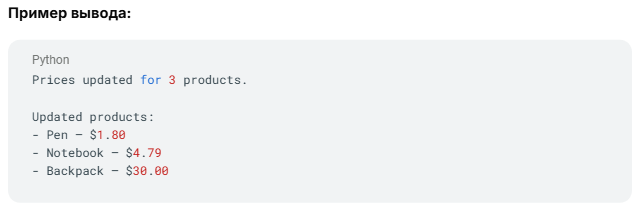

In [13]:
higher_price = collection.update_many(
    {},
    {"$mul": {"price": 1.2}})
print(f"Prices updated for {higher_price.matched_count} products.")
print("Updated product:")
for row in collection.find():
    print(f"- {row['name']} - ${row['price']:.2f}")
conn_edit.close()

Prices updated for 3 products.
Updated product:
- Laptop - $1199.99
- Smartphone - $599.99
- Headphones - $239.99
